In [1]:
import re
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
import scienceplots

In [2]:
df_tfd_base1 = pd.read_csv('../../cp/results_base1_tfd.csv')
df_tfd_base1 = df_tfd_base1.drop_duplicates(subset=['config','num_trains'])
df_tfd_base1 = df_tfd_base1.assign(planner='tfd', base='base1')

df_tfd_base2 = pd.read_csv('../../cp/results_base2_tfd.csv')
df_tfd_base2 = df_tfd_base2.drop_duplicates(subset=['config','num_trains'])
df_tfd_base2 = df_tfd_base2.assign(planner='tfd', base='base2')

df_tfd = pd.concat([df_tfd_base1, df_tfd_base2])

df_enhsp_base3 = pd.read_csv('../../cp/results_base3_enhsp.csv')
df_enhsp_base3 = df_enhsp_base3.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base3 = df_enhsp_base3.assign(planner='enhsp', base='base3')

df_enhsp_base4 = pd.read_csv('../../cp/results_base4_enhsp.csv')
df_enhsp_base4 = df_enhsp_base4.drop_duplicates(subset=['config','num_trains'])
df_enhsp_base4 = df_enhsp_base4.assign(planner='enhsp', base='base4')

df_enhsp = pd.concat([df_enhsp_base3, df_enhsp_base4])

df_mff_base3 = pd.read_csv('../../cp/results_base3_metricff.csv')
df_mff_base3 = df_mff_base3.drop_duplicates(subset=['config','num_trains'])
df_mff_base3 = df_mff_base3.assign(planner='metricff', base='base3')

df_mff = df_mff_base3.copy()

df_nfd_base3 = pd.read_csv('../../cp/results_base3_nfd.csv')
df_nfd_base3 = df_nfd_base3.drop_duplicates(subset=['config','num_trains'])
df_nfd_base3 = df_nfd_base3.assign(planner='nfd', base='base3')

# df_nfd_base4 = pd.read_csv('../../cp/results_base4_nfd.csv')
# df_nfd_base4 = df_nfd_base4.drop_duplicates(subset=['config','num_trains'])
# df_nfd_base4 = df_nfd_base4.assign(planner='nfd', base='base4')

df_nfd = pd.concat([df_nfd_base3])#, df_nfd_base4])

df_base1 = df_tfd_base1.copy()
df_base2 = df_tfd_base2.copy()
df_base3 = pd.concat([df_enhsp_base3, df_mff_base3, df_nfd_base3])
df_base4 = pd.concat([df_enhsp_base4])#, df_nfd_base4])

df_temporal = pd.concat([df_base1, df_base2])
df_numeric = pd.concat([df_base3, df_base4])


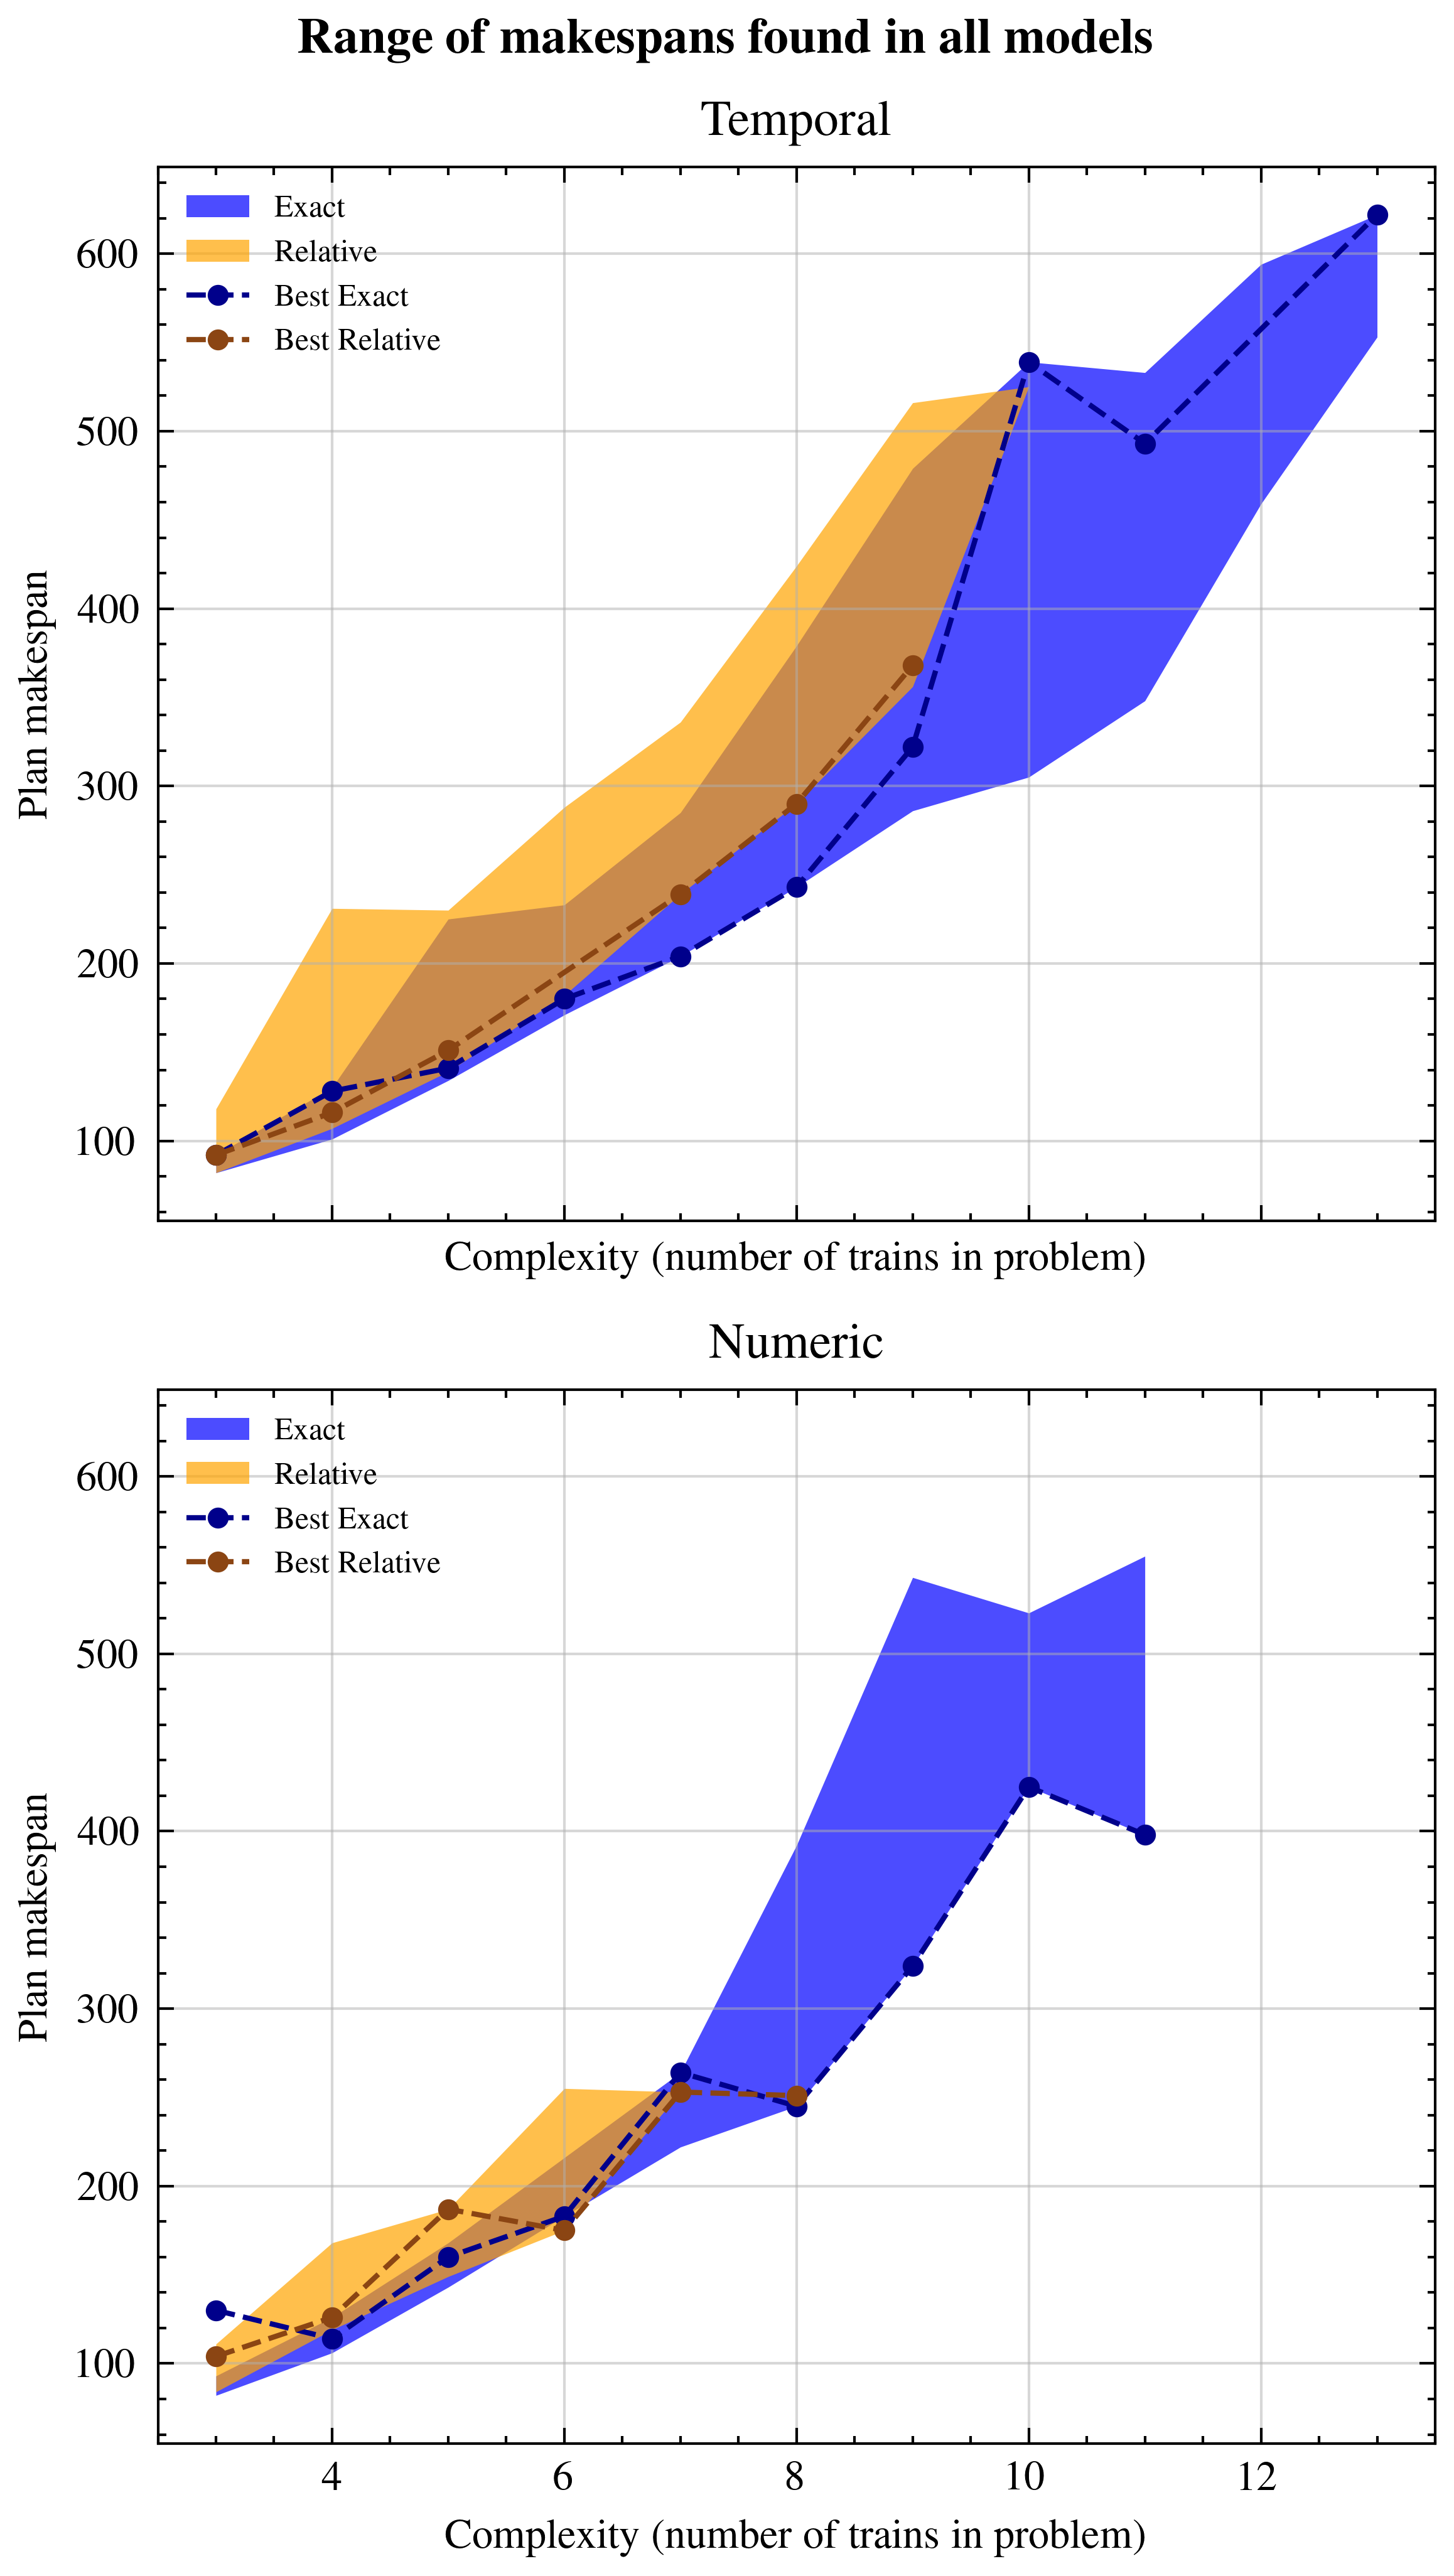

In [13]:
base1_y1, base1_y2 = [], []
base2_y1, base2_y2 = [], []
base3_y1, base3_y2 = [], []
base4_y1, base4_y2 = [], []
base1_x = []
base2_x = []
base3_x = []
base4_x = []

for i in range(3,20):
    df_base1_filt = df_base1.query(f"num_trains=={i}")
    base1_makespans = sorted(df_base1_filt['makespan_pp'])
    max_idx = min(len(base1_makespans)-1,9)
    if len(base1_makespans)> 0:
        base1_y1.append(base1_makespans[0])
        base1_y2.append(base1_makespans[max_idx])
        base1_x.append(i)

    df_base2_filt = df_base2.query(f"num_trains=={i}")
    base2_makespans = sorted(df_base2_filt['makespan_pp'])
    max_idx = min(len(base2_makespans)-1,9)
    if len(base2_makespans)> 0:
        base2_y1.append(base2_makespans[0])
        base2_y2.append(base2_makespans[max_idx])
        base2_x.append(i)

    df_base3_filt = df_base3.query(f"num_trains=={i}")
    base3_makespans = sorted(df_base3_filt['makespan_pp'])
    max_idx = min(len(base3_makespans)-1,9)
    if len(base3_makespans)> 0:
        base3_y1.append(base3_makespans[0])
        base3_y2.append(base3_makespans[max_idx])
        base3_x.append(i)

    df_base4_filt = df_base4.query(f"num_trains=={i}")
    base4_makespans = sorted(df_base4_filt['makespan_pp'])
    max_idx = min(len(base4_makespans)-1,9)
    if len(base4_makespans)> 0:
        base4_y1.append(base4_makespans[0])
        base4_y2.append(base4_makespans[max_idx])
        base4_x.append(i)

df_best_base1 = df_base1.query('planner=="tfd" and config==3')
df_best_base2 = df_base2.query('planner=="tfd" and config==6')
df_best_base3 = df_base3.query('planner=="enhsp" and config==6')
df_best_base4 = df_base4.query('planner=="enhsp" and config==6')

plt.style.use(['ieee', 'science'])

fig, ax = plt.subplots(2,1, figsize=(4,7), sharex=True, sharey=True)
fig.suptitle(r"""\textbf{Range of makespans found in all models}""")
ax[0].set_title('Temporal')
ax[0].fill_between(base1_x, base1_y1, base1_y2, alpha=0.7, linewidth=0, label='Exact', color='blue')
ax[0].fill_between(base2_x, base2_y1, base2_y2, alpha=0.7, linewidth=0, label='Relative', color='orange')
ax[0].plot(df_best_base1['num_trains'], df_best_base1['makespan_pp'], '.--', label='Best Exact', color='darkblue')
ax[0].plot(df_best_base2['num_trains'], df_best_base2['makespan_pp'], '.--', label='Best Relative', color='saddlebrown')
ax[0].grid(True, alpha=0.5)
ax[0].set_ylabel('Plan makespan')
ax[0].set_xlabel('Complexity (number of trains in problem)')
ax[0].legend(loc='upper left', fontsize=6)

ax[1].set_title('Numeric')
ax[1].fill_between(base3_x, base3_y1, base3_y2, alpha=0.7, linewidth=0, label='Exact', color='blue')
ax[1].fill_between(base4_x, base4_y1, base4_y2, alpha=0.7, linewidth=0, label='Relative', color='orange')
ax[1].plot(df_best_base3['num_trains'], df_best_base3['makespan_pp'], '.--', label='Best Exact', color='darkblue')
ax[1].plot(df_best_base4['num_trains'], df_best_base4['makespan_pp'], '.--', label='Best Relative', color='saddlebrown')
ax[1].grid(True, alpha=0.5)
ax[1].set_ylabel('Plan makespan')
ax[1].set_xlabel('Complexity (number of trains in problem)')
ax[1].legend(loc='upper left', fontsize=6)

plt.tight_layout()

fig.savefig('exact_relative.png')
